# Titanic: Machine Learning from Disaster

## Overview
This project is based on the [Kaggle Titanic competition](https://www.kaggle.com/competitions/titanic), one of the most well-known introductory machine learning challenges. The goal is to predict which passengers survived the Titanic shipwreck using demographic and travel information.

## Goal
Build a binary classification model predicting whether a passenger survived (1) or did not survive (0) based on features such as age, sex, passenger class, fare and family composition.

## Evaluation Metrics
Models are primarily compared on **accuracy** across training, validation and test sets. The `classification_report` output additionally provides precision, recall and F1 score for reference, though given the relatively balanced class distribution (62/38) and the historical nature of the dataset, accuracy serves as the main comparison metric.

## Approach
The project follows a complete machine learning pipeline:
- Exploratory Data Analysis
- Data preprocessing including imputation, encoding and feature scaling
- Feature engineering (family size, is alone)
- Training and comparing Logistic Regression, KNN, Random Forest and Gradient Boosting
- Hyperparameter tuning using GridSearchCV
- Evaluation on a held-out test set

## Tools
Exploratory data analysis was performed using **QuickEDA**, a custom-built tool designed to accelerate the initial data exploration phase of any machine learning project. Rather than re-running the same EDA cells for every CSV, QuickEDA lets you upload a file and instantly see its shape, column types, summary statistics, missing value counts, duplicate rows and a correlation matrix — all through an interactive interface instead of manual pandas calls. It was used throughout this project to quickly sanity-check the raw data and intermediate transformations.

→ [QuickEDA on GitHub](https://github.com/wdeltenre/QuickEDA)

# 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df_raw = pd.read_csv("Titanic-Dataset.csv")
df = df_raw.copy()

# 2. Data Preprocessing

## 2.1 Train / Validation / Test Split

In [2]:
def divide_data_set(df: pd.DataFrame):
    X = df.drop(columns=["Survived"])
    y = df["Survived"]
    
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

## 2.2 Missing Value Imputation

In [3]:
def imputer(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    # Most common
    most_common_embarked = X_train["Embarked"].mode().iloc[0]
    X_train["Embarked"] = X_train["Embarked"].fillna(most_common_embarked)
    X_val["Embarked"] = X_val["Embarked"].fillna(most_common_embarked)
    X_test["Embarked"] = X_test["Embarked"].fillna(most_common_embarked)
    
    # KNN
    knn = KNNImputer(n_neighbors=5)
    cols = ["Age", "Pclass", "SibSp", "Parch", "Fare"]
    X_train[cols] = knn.fit_transform(X_train[cols])
    X_val[cols] = knn.transform(X_val[cols])
    X_test[cols] = knn.transform(X_test[cols])

    return X_train, X_val, X_test

## 2.3 Categorical Encoding

In [4]:
def OHEencoding(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
    
    encoder.fit(X_train[["Sex", "Embarked"]])
    
    encoded_cols = encoder.get_feature_names_out(["Sex", "Embarked"])
    
    X_train[encoded_cols] = encoder.transform(X_train[["Sex", "Embarked"]])
    X_val[encoded_cols]   = encoder.transform(X_val[["Sex", "Embarked"]])
    X_test[encoded_cols]  = encoder.transform(X_test[["Sex", "Embarked"]])
    
    # Drop the original column
    X_train = X_train.drop(columns=["Sex", "Embarked"])
    X_val   = X_val.drop(columns=["Sex", "Embarked"])
    X_test  = X_test.drop(columns=["Sex", "Embarked"])

    return X_train, X_val, X_test

## 2.4 Feature Engineering

In [5]:
def feature_engineering(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    for dataset in [X_train, X_val, X_test]:
        dataset["FamilySize"] = dataset["SibSp"] + dataset["Parch"] + 1  # +1 for the passenger themselves
        
        dataset["IsAlone"] = (dataset["FamilySize"] == 1).astype(int)
    
    return X_train, X_val, X_test # Keeping SibSp & Parch as well

## 2.5 Feature Scaling

In [6]:
def feature_scaling(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    # Standardization
    standard_scaler = StandardScaler()
    X_train[["Age"]] = standard_scaler.fit_transform(X_train[["Age"]])
    X_val[["Age"]]   = standard_scaler.transform(X_val[["Age"]])
    X_test[["Age"]]  = standard_scaler.transform(X_test[["Age"]])
    
    # Robust scaling
    robust_scaler = RobustScaler()
    X_train[["Fare"]] = robust_scaler.fit_transform(X_train[["Fare"]])
    X_val[["Fare"]]   = robust_scaler.transform(X_val[["Fare"]])
    X_test[["Fare"]]  = robust_scaler.transform(X_test[["Fare"]])
    
    return X_train, X_val, X_test

## 2.6 Preprocessing Pipeline

In [7]:
def preprocessing(df: pd.DataFrame):
    # Remove obsolete columns
    df_copy = df.copy().drop(columns=["PassengerId", "Cabin", "Ticket", "Name"])

    # Divide data set
    X_train, X_val, X_test, y_train, y_val, y_test = divide_data_set(df_copy)
    
    # Impute
    X_train, X_val, X_test = imputer(X_train, X_val, X_test)

    # Encoding
    X_train, X_val, X_test = OHEencoding(X_train, X_val, X_test)

    # Feature engineering
    X_train, X_val, X_test = feature_engineering(X_train, X_val, X_test)

    # Feature 
    X_train, X_val, X_test = feature_scaling(X_train, X_val, X_test)

    # No outliers should could issues, as fare was scaled using the median

    return X_train, X_val, X_test, y_train, y_val, y_test
    
X_train, X_val, X_test, y_train, y_val, y_test = preprocessing(df)

In [8]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize,IsAlone
577,1.0,0.634932,1.0,0.0,1.872994,0.0,0.0,1.0,2.0,0
63,3.0,-1.970820,3.0,2.0,0.607635,1.0,0.0,1.0,6.0,0
424,3.0,-0.928519,1.0,1.0,0.260226,1.0,0.0,1.0,3.0,0
513,1.0,1.751683,1.0,0.0,2.031164,0.0,0.0,0.0,2.0,0
610,3.0,0.634932,1.0,5.0,0.760156,0.0,0.0,1.0,7.0,0
...,...,...,...,...,...,...,...,...,...,...
451,3.0,-0.094678,1.0,0.0,0.249118,1.0,0.0,1.0,2.0,0
780,3.0,-1.300769,0.0,0.0,-0.326508,0.0,0.0,0.0,1.0,1
819,3.0,-1.524120,3.0,2.0,0.607635,1.0,0.0,1.0,6.0,0
812,2.0,0.337132,0.0,0.0,-0.178696,1.0,0.0,1.0,1.0,1


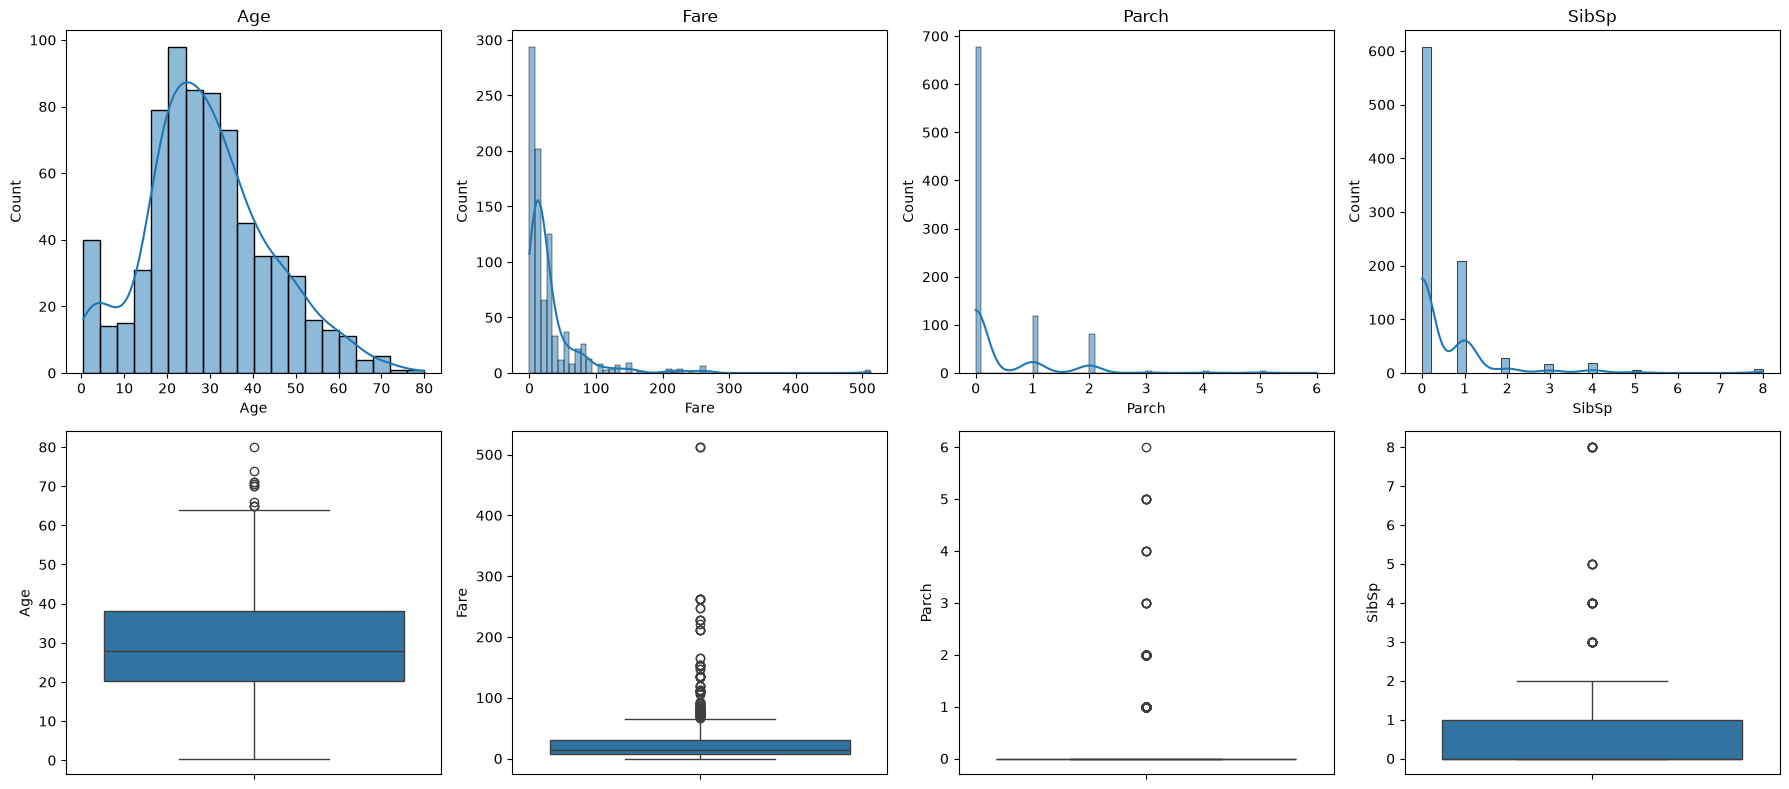

Age: 11 outliers
Fare: 116 outliers
Parch: 213 outliers
SibSp: 46 outliers


In [9]:
numeric_cols = ["Age", "Fare", "Parch", "SibSp"]

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(col)
    
    sns.boxplot(y=df_raw[col], ax=axes[1, i])

plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_raw[(df_raw[col] < Q1 - 1.5 * IQR) | (df_raw[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

# 3. Model Training

In [10]:
# ----- DUMMY ALGORITHM -----
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Baseline accuracy: {dummy.score(X_val, y_val):.4f}")

Baseline accuracy: 0.6180


## 3.1 Logistic Regression

In [11]:
# ----- LOGISTIC REGRESSION -----
def tune_logistic_regression(X_train, y_train):
    param_grid = {
        "C"          : [0.01, 0.1, 1, 10, 100],
        "max_iter"   : [100, 500, 1000],
        "fit_intercept": [True, False]
    }
    grid = GridSearchCV(
        LogisticRegression(random_state=42),
        param_grid, cv=5, scoring="accuracy", n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"Logistic Regression best params : {grid.best_params_}")
    print(f"Logistic Regression best CV score: {grid.best_score_:.4f}")
    return grid.best_estimator_

lr_model  = tune_logistic_regression(X_train, y_train)

Logistic Regression best params : {'C': 0.1, 'fit_intercept': True, 'max_iter': 100}
Logistic Regression best CV score: 0.8014


## 3.2 K-Nearest Neighbors

In [12]:
# ----- KNN -----
def tune_knn(X_train, y_train):
    param_grid = {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "metric"     : ["euclidean", "manhattan"],
        "weights"    : ["uniform", "distance"]
    }
    grid = GridSearchCV(KNeighborsClassifier(),
                        param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"KNN best params : {grid.best_params_}")
    print(f"KNN best CV score: {grid.best_score_:.4f}")
    return grid.best_estimator_

knn_model = tune_knn(X_train, y_train)

KNN best params : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
KNN best CV score: 0.7884


## 3.3 Random Forest

In [13]:
# ----- RANDOM FOREST -----
def tune_random_forest(X_train, y_train):
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth"   : [3, 5, 10, None],
        "min_samples_leaf": [1, 2, 5]
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42),
                        param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Random Forest best params : {grid.best_params_}")
    print(f"Random Forest best CV score: {grid.best_score_:.4f}")
    return grid.best_estimator_

rf_model  = tune_random_forest(X_train, y_train)

Random Forest best params : {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 300}
Random Forest best CV score: 0.8126


## 3.4 Gradient Boosting

In [14]:
# ----- GRADIENT BOOSTING -----
def tune_gradient_boosting(X_train, y_train):
    param_grid = {
        "n_estimators" : [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth"    : [3, 5, 7]
    }
    grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                        param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Gradient Boosting best params : {grid.best_params_}")
    print(f"Gradient Boosting best CV score: {grid.best_score_:.4f}")
    return grid.best_estimator_

gb_model  = tune_gradient_boosting(X_train, y_train)

Gradient Boosting best params : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting best CV score: 0.8164


In [16]:
## 3.5 Xgboost

In [15]:
def tune_xgboost(X_train, y_train):
    param_grid = {
        "n_estimators"    : [100, 200, 300],
        "learning_rate"   : [0.01, 0.05, 0.1],
        "max_depth"       : [3, 5, 7],
        "subsample"       : [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
    grid = GridSearchCV(
        xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
        param_grid, cv=5, scoring="accuracy", n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"XGBoost best params : {grid.best_params_}")
    print(f"XGBoost best CV score: {grid.best_score_:.4f}")
    return grid.best_estimator_

xgb_model = tune_xgboost(X_train, y_train)

XGBoost best params : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
XGBoost best CV score: 0.8258


# 4. Model Evaluation

In [17]:
models = {
    "Logistic Regression"  : lr_model,
    "Random Forest"        : rf_model,
    "Gradient Boosting"    : gb_model,
    "KNN"                  : knn_model,
    "Xgboost"              : xgb_model
}

print("\n--- Validation Accuracy Comparison ---")
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"{name:25s} : {accuracy_score(y_val, y_pred):.4f}")


--- Validation Accuracy Comparison ---
Logistic Regression       : 0.7978
Random Forest             : 0.8427
Gradient Boosting         : 0.8427
KNN                       : 0.8090
Xgboost                   : 0.8371


In [18]:
models = {
    "Logistic Regression"  : lr_model,
    "Random Forest"        : rf_model,
    "Gradient Boosting"    : gb_model,
    "KNN"                  : knn_model,
    "Xgboost"              : xgb_model
}

print("\n--- Validation Accuracy Comparison ---")
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"{name:25s} : {accuracy_score(y_val, y_pred):.4f}")


--- Validation Accuracy Comparison ---
Logistic Regression       : 0.7978
Random Forest             : 0.8427
Gradient Boosting         : 0.8427
KNN                       : 0.8090
Xgboost                   : 0.8371


In [19]:
print("--- Final Test Set Results ---\n")
for name, model in {"Logistic Regression": lr_model,
                     "Random Forest"      : rf_model,
                     "Gradient Boosting"  : gb_model,
                     "KNN"                : knn_model,
                     "Xgboost"            : xgb_model}.items():
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print()

--- Final Test Set Results ---

Logistic Regression
  Accuracy : 0.7877
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       110
           1       0.78      0.62      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179


Random Forest
  Accuracy : 0.7877
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       110
           1       0.79      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179


Gradient Boosting
  Accuracy : 0.7765
              precision    recall  f1-score   support

           0       0.77      0.92      0.83       110
           1       0.81      0.55      0.66        69

    accuracy                        

## 5. Conclusion

### Model Performance Summary

| Model | Accuracy | Precision (1) | Recall (1) | F1 (1) |
|---|---|---|---|---|
| XGBoost | 0.7933 | 0.82 | 0.59 | 0.69 |
| Logistic Regression | 0.7877 | 0.78 | 0.62 | 0.69 |
| Random Forest | 0.7877 | 0.79 | 0.61 | 0.69 |
| Gradient Boosting | 0.7765 | 0.81 | 0.55 | 0.66 |
| KNN | 0.7654 | 0.71 | 0.67 | 0.69 |

### Key Takeaways

**XGBoost edged out the competition** at 79.3% accuracy, though the margin over Logistic Regression and Random Forest is minimal. The fact that a simple linear model like Logistic Regression closely matches complex ensemble methods suggests the survival patterns in this dataset are largely linearly separable given the engineered features.

**All models struggled to identify survivors (class 1)** — recall for class 1 ranges from 0.55 to 0.67 across all models. This is the most challenging aspect of this problem: the models are conservative about predicting survival, erring toward the majority class.

**Gradient Boosting showed the lowest recall for survivors (0.55)** despite having strong precision for that class (0.81). It is the most conservative model — when it predicts survival it is usually right, but it misses nearly half of actual survivors.

**KNN performed worst overall** at 76.5% accuracy, consistent with expectations for a distance-based algorithm on a small mixed-feature dataset. It did however achieve the most balanced recall across both classes, suggesting it generalizes more evenly than the boosting methods.

### Limitations

All five models share the same performance ceiling — the features available in the dataset. Key survival factors such as exact location on the ship at impact, physical fitness, and proximity to lifeboats are entirely absent from the data. These represent irreducible error that no amount of model improvement can overcome.